# Revio â€” EDA (Exploratory Data Analysis)

This notebook explores the Car Diagnostics Dataset before any model training.

**Sections**
1. Dataset inventory â€” file counts, sizes, durations
2. Class distribution â€” bar charts per state
3. Waveform visualisation â€” sample clips per class
4. MFCC heatmaps â€” one per class per state
5. Audio property summary â€” sample rates, channel counts, clipping check

In [1]:
import sys, os
# Make src/ importable from notebooks/
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None

from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import soundfile as sf

from src.preprocess import (
    load_audio, extract_mfcc,
    BRAKING_LABELS, STARTUP_LABELS, IDLE_LABELS, IDLE_SKIP,
    SAMPLE_RATE, DURATION, N_MFCC,
)

DATA_DIR = Path('data/raw')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
print('Setup complete.')


Setup complete.


## 1 â€” Dataset Inventory

In [2]:
STATES = {
    'Braking':  (DATA_DIR / 'braking state',  BRAKING_LABELS,  set()),
    'Start-Up': (DATA_DIR / 'startup state',  STARTUP_LABELS,  set()),
    'Idle':     (DATA_DIR / 'idle state',     IDLE_LABELS,     IDLE_SKIP),
}

inventory = []   # list of dicts for tabular display

for state_name, (state_dir, label_map, skip) in STATES.items():
    for class_name, label in label_map.items():
        class_dir = state_dir / class_name
        wavs = sorted(class_dir.glob('*.wav'))
        total_bytes = sum(w.stat().st_size for w in wavs)
        inventory.append({
            'State':      state_name,
            'Class':      class_name,
            'Label':      label,
            'Files':      len(wavs),
            'Size (MB)':  round(total_bytes / 1e6, 2),
        })

# Print as a simple table
header = f"{'State':<10} {'Class':<28} {'Lbl':>3}  {'Files':>5}  {'MB':>6}"
print(header)
print('-' * len(header))
total_files = 0
for row in inventory:
    print(f"{row['State']:<10} {row['Class']:<28} {row['Label']:>3}  "
          f"{row['Files']:>5}  {row['Size (MB)']:>6}")
    total_files += row['Files']
print('-' * len(header))
print(f"{'TOTAL':<10} {'':28} {'':>3}  {total_files:>5}")

State      Class                        Lbl  Files      MB
----------------------------------------------------------
Braking    normal_brakes                  0     77    9.26
Braking    worn_out_brakes                1     76   10.06
Start-Up   normal_engine_startup          0     61    9.15
Start-Up   bad_ignition                   1     62     9.3
Start-Up   dead_battery                   2     57    8.55
Idle       normal_engine_idle             0    264   34.94
Idle       low_oil                        1    107   14.16
Idle       power_steering                 2    129   17.07
Idle       serpentine_belt                3    116   15.35
----------------------------------------------------------
TOTAL                                          949


## 2 â€” Class Distribution

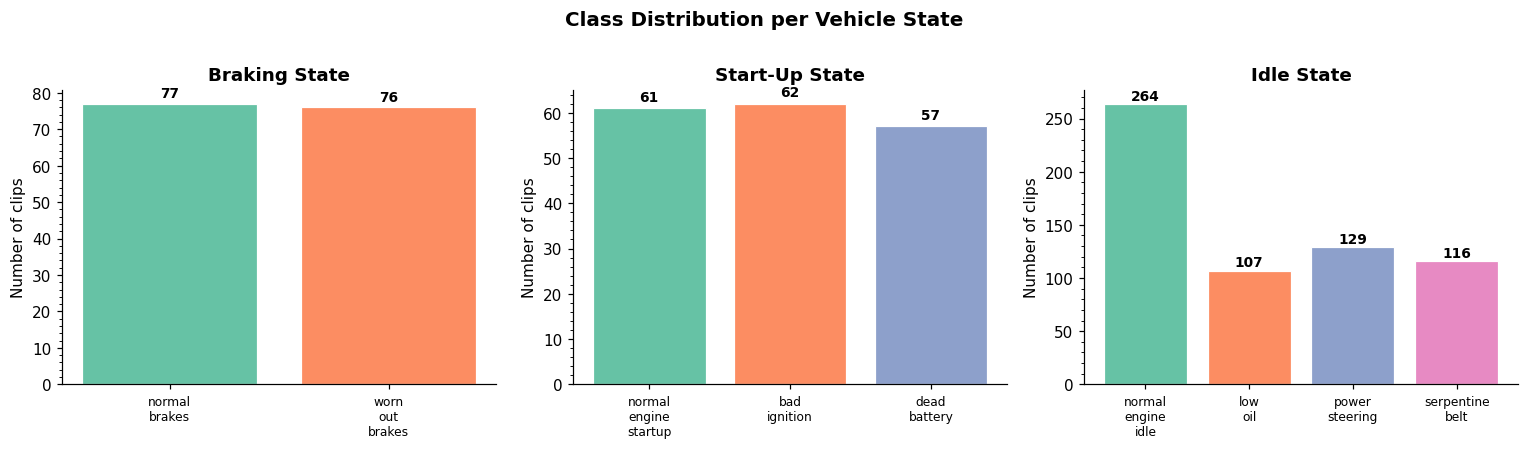

Saved â†’ results/class_distribution.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = plt.cm.Set2.colors

for ax, (state_name, (state_dir, label_map, skip)) in zip(axes, STATES.items()):
    classes  = list(label_map.keys())
    counts   = [len(list((state_dir / c).glob('*.wav'))) for c in classes]
    bars = ax.bar(range(len(classes)), counts,
                  color=colors[:len(classes)], edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels([c.replace('_', '\n') for c in classes], fontsize=8)
    ax.set_title(f'{state_name} State', fontweight='bold')
    ax.set_ylabel('Number of clips')
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    # Annotate bar heights
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Class Distribution per Vehicle State', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved â†’ results/class_distribution.png')

## 3 â€” Waveform Visualisation

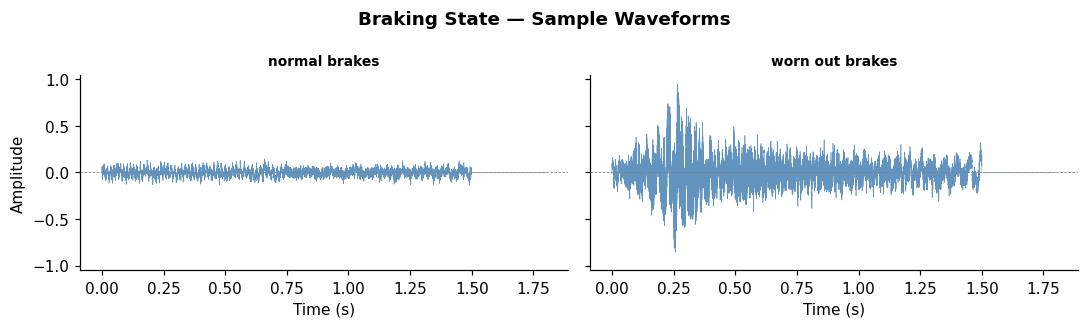

Saved â†’ results\waveforms_braking.png


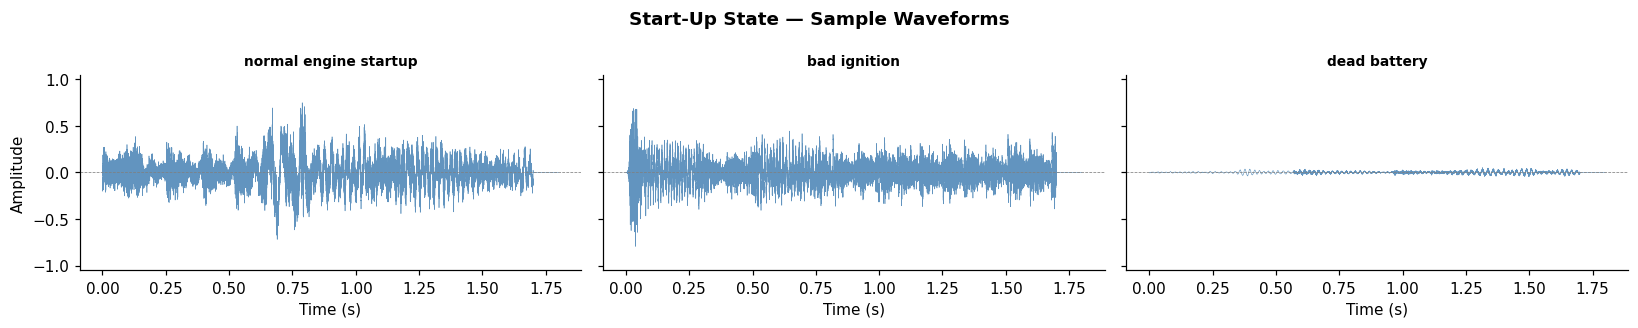

Saved â†’ results\waveforms_start_up.png


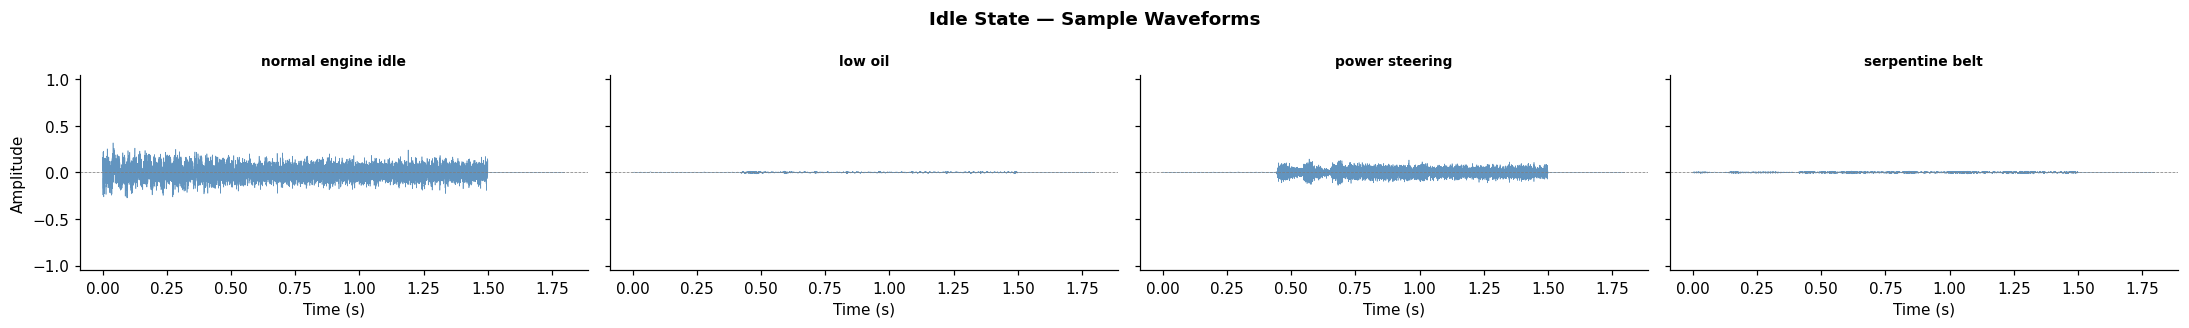

Saved â†’ results\waveforms_idle.png


In [4]:
def plot_waveforms(state_name, state_dir, label_map, skip=set()):
    classes = [c for c in label_map if c not in skip]
    n = len(classes)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3), sharey=True)
    if n == 1:
        axes = [axes]
    t = np.linspace(0, DURATION, int(SAMPLE_RATE * DURATION))

    for ax, class_name in zip(axes, classes):
        wav = sorted((state_dir / class_name).glob('*.wav'))[0]
        audio = load_audio(str(wav))
        ax.plot(t, audio, linewidth=0.4, color='steelblue', alpha=0.85)
        ax.set_title(class_name.replace('_', ' '), fontsize=9, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.set_ylim(-1.05, 1.05)
        ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    axes[0].set_ylabel('Amplitude')

    fig.suptitle(f'{state_name} State â€” Sample Waveforms', fontweight='bold')
    plt.tight_layout()
    out = Path(f'results/waveforms_{state_name.lower().replace("-","_")}.png')
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved â†’ {out}')

for state_name, (state_dir, label_map, skip) in STATES.items():
    plot_waveforms(state_name, state_dir, label_map, skip)

## 4 â€” MFCC Heatmaps

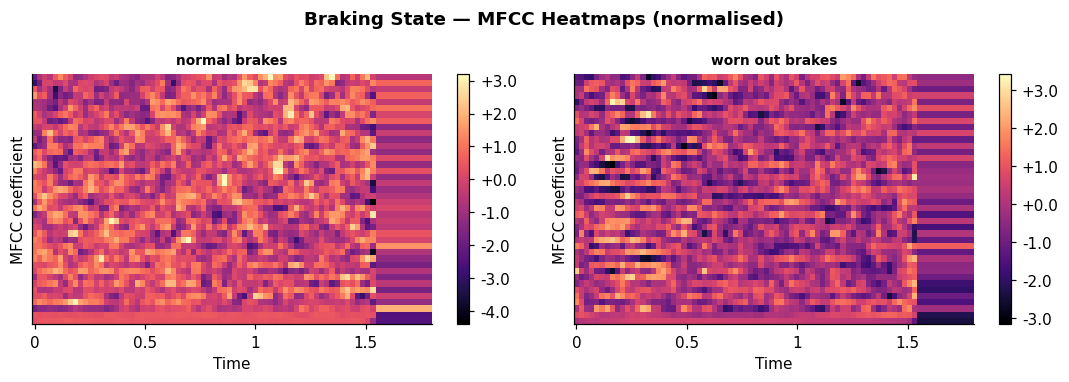

Saved â†’ results\mfcc_braking.png


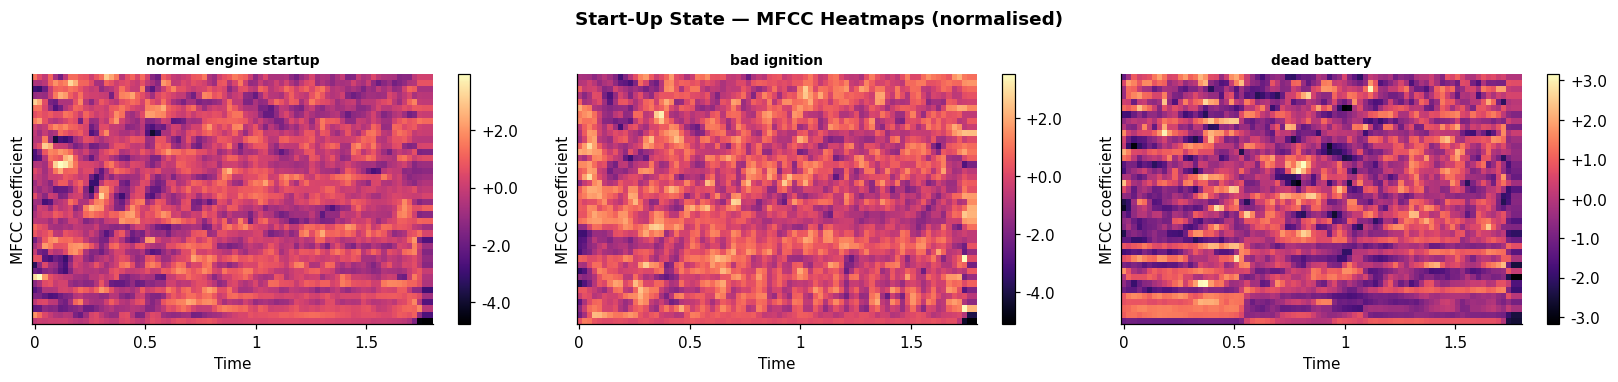

Saved â†’ results\mfcc_start_up.png


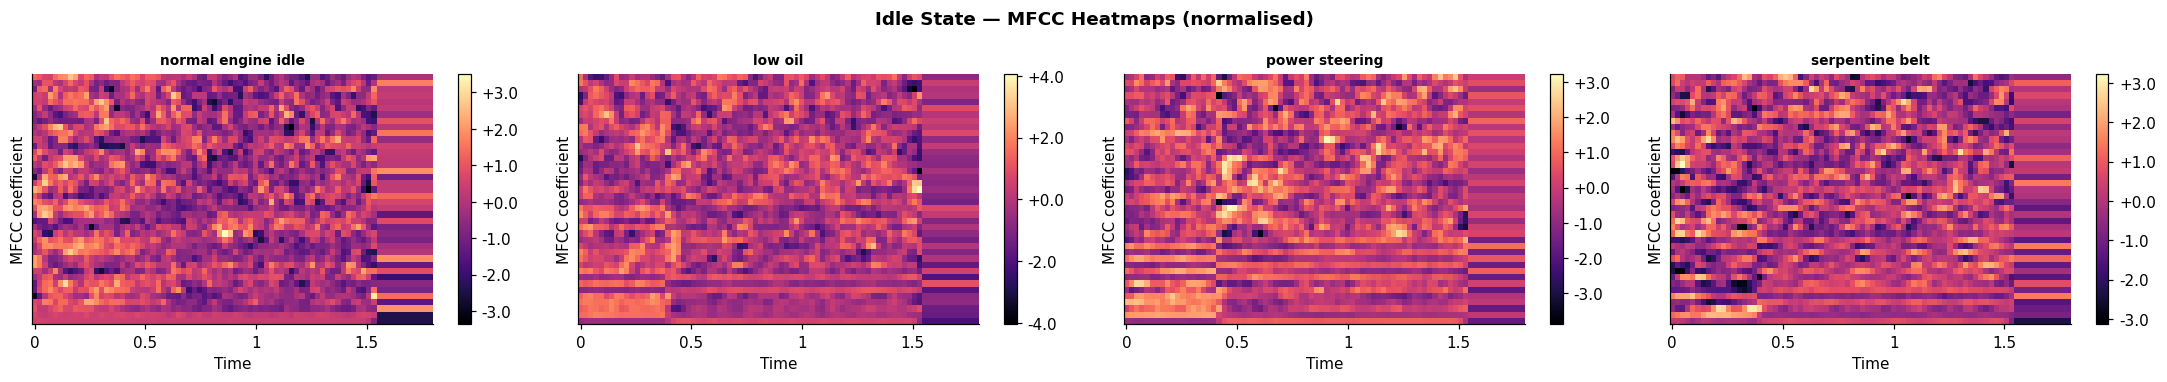

Saved â†’ results\mfcc_idle.png


In [5]:
def plot_mfcc_heatmaps(state_name, state_dir, label_map, skip=set()):
    classes = [c for c in label_map if c not in skip]
    n = len(classes)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.5))
    if n == 1:
        axes = [axes]

    for ax, class_name in zip(axes, classes):
        wav = sorted((state_dir / class_name).glob('*.wav'))[0]
        audio = load_audio(str(wav))
        mfcc  = extract_mfcc(audio)
        img = librosa.display.specshow(
            mfcc, sr=SAMPLE_RATE, hop_length=512,
            x_axis='time', ax=ax, cmap='magma'
        )
        ax.set_title(class_name.replace('_', ' '), fontsize=9, fontweight='bold')
        ax.set_ylabel('MFCC coefficient')
        fig.colorbar(img, ax=ax, format='%+.1f')

    fig.suptitle(f'{state_name} State â€” MFCC Heatmaps (normalised)', fontweight='bold')
    plt.tight_layout()
    out = Path(f'results/mfcc_{state_name.lower().replace("-","_")}.png')
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved â†’ {out}')

for state_name, (state_dir, label_map, skip) in STATES.items():
    plot_mfcc_heatmaps(state_name, state_dir, label_map, skip)

## 5 â€” Audio Property Summary

In [6]:
sample_rates, channels, durations, clipped = [], [], [], []

for state_name, (state_dir, label_map, skip) in STATES.items():
    for class_name in label_map:
        for wav_path in (state_dir / class_name).glob('*.wav'):
            info = sf.info(str(wav_path))
            sample_rates.append(info.samplerate)
            channels.append(info.channels)
            durations.append(info.duration)
            # Clipping check: any sample at Â±1
            audio_raw, _ = sf.read(str(wav_path))
            clipped.append(bool(np.any(np.abs(audio_raw) >= 0.999)))

sample_rates = np.array(sample_rates)
durations    = np.array(durations)
channels     = np.array(channels)

print(f"Total files analysed : {len(durations)}")
print(f"Sample rates (unique): {np.unique(sample_rates).tolist()}")
print(f"Channel counts       : {np.unique(channels).tolist()}")
print(f"Duration (s)  min={durations.min():.2f}  max={durations.max():.2f}  "
      f"mean={durations.mean():.2f}  std={durations.std():.2f}")
print(f"Clips >= target {DURATION}s : "
      f"{(durations >= DURATION).sum()} / {len(durations)}")
print(f"Clips shorter than {DURATION}s: "
      f"{(durations < DURATION).sum()} (will be zero-padded)")
print(f"Clipped files (|x| >= 0.999): {sum(clipped)}")

Total files analysed : 949
Sample rates (unique): [24000, 44100, 48000]
Channel counts       : [1]
Duration (s)  min=1.50  max=1.70  mean=1.54  std=0.08
Clips >= target 1.8s : 0 / 949
Clips shorter than 1.8s: 949 (will be zero-padded)
Clipped files (|x| >= 0.999): 6


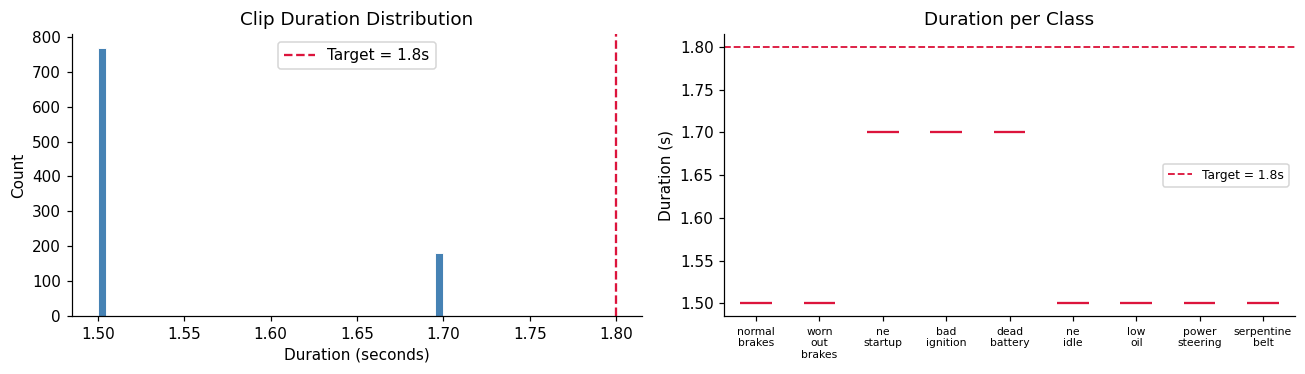

Saved â†’ results/duration_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Duration distribution
axes[0].hist(durations, bins=40, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].axvline(DURATION, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Target = {DURATION}s')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Clip Duration Distribution')
axes[0].legend()

# Duration per class (box plot)
class_durations = {}
for state_name, (state_dir, label_map, skip) in STATES.items():
    for class_name in label_map:
        durs = [sf.info(str(w)).duration
                for w in (state_dir / class_name).glob('*.wav')]
        short_name = class_name.replace('normal_engine_', 'ne_')
        class_durations[short_name] = durs

keys = list(class_durations.keys())
vals = [class_durations[k] for k in keys]
bp = axes[1].boxplot(vals, patch_artist=True, vert=True,
                     medianprops=dict(color='crimson', linewidth=1.5))
for patch, color in zip(bp['boxes'], plt.cm.Set2.colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_xticks(range(1, len(keys) + 1))
axes[1].set_xticklabels([k.replace('_', '\n') for k in keys], fontsize=7)
axes[1].axhline(DURATION, color='crimson', linestyle='--', linewidth=1.2,
                label=f'Target = {DURATION}s')
axes[1].set_ylabel('Duration (s)')
axes[1].set_title('Duration per Class')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/duration_analysis.png', bbox_inches='tight')
plt.show()
print('Saved â†’ results/duration_analysis.png')

## 6 â€” Global MFCC Statistics (sanity check before training)

In [8]:
from src.preprocess import load_braking_dataset, load_startup_dataset, load_idle_dataset

datasets = {
    'Braking':  load_braking_dataset('data/raw'),
    'Start-Up': load_startup_dataset('data/raw'),
    'Idle':     load_idle_dataset('data/raw'),
}

print(f"{'State':<10} {'Shape':<22} {'X min':>7} {'X max':>7} {'X mean':>7} {'X std':>7}")
print('-' * 65)
for name, (X, y, labels) in datasets.items():
    print(f"{name:<10} {str(X.shape):<22} {X.min():>7.3f} {X.max():>7.3f} "
          f"{X.mean():>7.3f} {X.std():>7.3f}")

Loading Braking dataset from: data\raw\braking state
  [0] normal_brakes                    77 files
  [1] worn_out_brakes                  76 files
Loading Start-Up dataset from: data\raw\startup state
  [0] normal_engine_startup            61 files
  [1] bad_ignition                     62 files
  [2] dead_battery                     57 files
Loading Idle dataset from: data\raw\idle state
  [0] normal_engine_idle              264 files
  [1] low_oil                         107 files
  [2] power_steering                  129 files
  [3] serpentine_belt                 116 files
State      Shape                    X min   X max  X mean   X std
-----------------------------------------------------------------
Braking    (153, 40, 78)           -5.515   5.676  -0.000   1.000
Start-Up   (180, 40, 78)           -5.793   7.380   0.000   1.000
Idle       (616, 40, 78)           -6.208   5.964   0.000   1.000


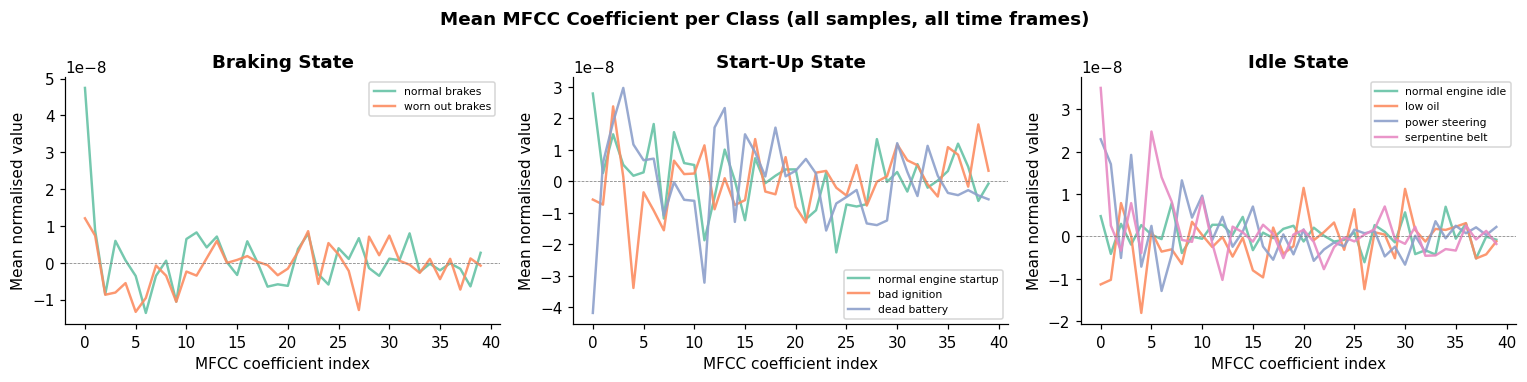

Saved â†’ results/mfcc_mean_per_class.png


In [9]:
# Mean MFCC coefficient magnitude per state â€” visualise which coefficients vary most
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)

for ax, (state_name, (X, y, labels)) in zip(axes, datasets.items()):
    colors = plt.cm.Set2.colors
    for label_idx, class_name in enumerate(labels):
        mask  = y == label_idx
        mean_coeff = X[mask].mean(axis=(0, 2))   # mean over samples and time â†’ (n_mfcc,)
        ax.plot(range(N_MFCC), mean_coeff, label=class_name.replace('_', ' '),
                color=colors[label_idx], linewidth=1.6, alpha=0.9)

    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_title(f'{state_name} State', fontweight='bold')
    ax.set_xlabel('MFCC coefficient index')
    ax.set_ylabel('Mean normalised value')
    ax.legend(fontsize=7)

fig.suptitle('Mean MFCC Coefficient per Class (all samples, all time frames)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('results/mfcc_mean_per_class.png', bbox_inches='tight')
plt.show()
print('Saved â†’ results/mfcc_mean_per_class.png')

## EDA Summary

| State | Classes | Total clips | Class imbalance? | Notes |
|---|---|---|---|---|
| Braking  | 2 | 153 | No (77 / 76) | Nearly perfectly balanced |
| Start-Up | 3 | 180 | Mild (61 / 62 / 57) | dead_battery has fewest; spread < 10% |
| Idle     | 4 | 616 | Yes (264 vs 107-129, ~2.5x) | Use class weights during training |

**Key findings:**

- **Duration:** all 949 clips are 1.50-1.70 s (mean 1.54 s, std 0.08 s) -- every clip is shorter than the 1.8 s window and will be zero-padded on the right
- **Sample rates:** three rates in the wild (24000 / 44100 / 48000 Hz) -- librosa resamples all to 22050 Hz on load
- **Channels:** all files are mono
- **Clipped files:** 6 / 949 (0.6%) -- negligible, no files need to be dropped
- **MFCC stats:** per-clip normalisation correct -- global mean ~0.000, std ~1.000 across all three datasets
- **Idle imbalance:** apply class_weight=balanced when training Model C
- **CNN input shape confirmed:** (40, 78, 1) for all three models
